# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3 - Septiembre 2024

**Rotación de Personal - IBM**

#### **Nombre y matrícula: José Eduardo De Moraes López A01634782**

#### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance":**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


In [ ]:
# Incluye aquí todas las librerías que consideres necesarias:
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)




Path to dataset files: /root/.cache/kagglehub/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/versions/1


# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

++++++++ Inicia la sección de agregar texto: ++++++++++++


El problema de rotación de personal se refiere a la pérdida de empleados en una organización, ya sea por renuncia, despido o jubilación. Este fenómeno puede generar costos elevados debido a la necesidad de contratar, capacitar y reintegrar nuevos empleados, además de perder conocimiento clave. Las empresas buscan identificar las causas de la rotación para implementar estrategias que minimicen su impacto y mejorar la retención del talento.


++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 2:**

#### **Carga los datos del archivo de la página de Kaggle indicada como un DataFrame de Pandas, llamado "df" y utilicemos el método “describe” con el argumento include= “all”, para obtener una primera descripción general de cada variable.**

In [ ]:
# ++++++++++++++ Inicia sección de agregar código ++++++++++++++++++++

df = pd.read_csv(path + "/WA_Fn-UseC_-HR-Employee-Attrition.csv")


# +++++++++++++ Termina sección de agregar código +++++++++++++++++++++


print("Tamaño del DataFrame:", df.shape)
df.describe(include = 'all').T


Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# **Ejercicio 3:**

#### **Indica cuál es la diferencia entre utilizar o no el argumento include=”all” del método "describe" en el ejercicio anterior.**

++++++++ Inicia la sección de agregar texto: ++++++++++++


El argumento include="all" del método describe() en pandas se utiliza para generar estadísticas descriptivas para todas las columnas del DataFrame, tanto numéricas como categóricas.
*   Con include="all": El método devuelve estadísticas descriptivas para todas las columnas, independientemente de si contienen datos numéricos o categóricos. Esto incluye estadísticas como el conteo de valores, el valor más frecuente (moda), la cantidad de valores únicos, la media, la desviación estándar, los percentiles, entre otros. Es útil para obtener una visión general de todas las variables en el conjunto de datos.
*   Sin include="all": El método solo devuelve estadísticas descriptivas para las columnas numéricas, como la media, la desviación estándar, los percentiles, el valor mínimo y máximo, etc. Las columnas categóricas (como las que contienen texto o etiquetas) no serán incluidas en el resumen.




++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 4:**

#### **Con base a la información desplegada por la instrucción anterior, hemos decidido cancelar los siguientes factores de nuestro problema: Over18, EmployeeCount, StandardHours, EmployeeNumber. Explica cuál es la justificación que nos permite cancelar cada uno de estos factores:**

++++++++ Inicia la sección de agregar texto: ++++++++++++

**a)   Over18**: Este factor solo contiene un valor constante, "Y", para todos los empleados presentando que todos son mayores de edad. No proporciona ninguna variabilidad o información útil sobre la rotación de personal, por lo que no es relevante para el análisis.

**b)	EmployeeCount**: Esta variable tiene un valor constante de "1" para todos los empleados. No aporta ninguna distinción entre los empleados y no tiene ningún valor predictivo respecto al problema de rotación de personal.

**c)	StandardHours**: Esta columna también tiene un valor constante de "80" para todos los empleados, lo que indica que no hay variabilidad en las horas estándar de trabajo. Al ser constante, no influye en la rotación de personal y no tiene relevancia para el análisis.

**d)	EmployeeNumber**: Esta columna tiene valores únicos para cada empleado, pero no contiene información relevante sobre las características o el comportamiento de los empleados. Es un identificador único que no tiene influencia directa en el fenómeno de la rotación de personal, por lo que puede ser descartada.

++++++++ Termina la sección de agregar texto. +++++++++++




In [ ]:
# Eliminamos los factores indicados:

df = df.drop(['Over18','EmployeeCount','StandardHours','EmployeeNumber'],axis=1)

print("Tamaño del nuevo DataFrame:", df.shape)

Tamaño del nuevo DataFrame: (1470, 31)


# **Ejercicio 5:**

#### **Realiza una partición de los datos en Entrenamiento, Validación y Prueba, del 70%, 15% y 15%, respectivamente. Llama a dichos conjuntos Xtrain, Xval, Xtest, ytrain, yval, ytest, para los datos de entrada y de salida, respectivamente. Asegúrate que dicha partición conserve la estratificación de las clases de la variable “Attrition”. Despliega además la dimensión obtenida de los tres conjuntos: Entrenamiento, Validación y Prueba.**

#### **NOTA: Utiliza semillas en cada función de partición, para permitir la repetibilidad de tu modelo y poder evaluarlo de mejor majera.**

In [ ]:
# ++++++++++++++ Inicia sección de agregar código +++++++++++++++++++++

# Primer paso: particionar 85% para entrenamiento+validación y 15% para prueba
X = df.drop(columns=['Attrition'])  # Elimina la columna 'Attrition' de las características
Y = df['Attrition']
Xtv, Xtest, ytv, ytest = train_test_split(X, Y,
                                          test_size=0.15,
                                          stratify=Y,   # Estratificación de la variable "Attrition"
                                          random_state=1)  # Semilla para asegurar la repetibilidad

# Segundo paso: particionar 85% en entrenamiento (70% total) y validación (15% total)
Xtrain, Xval, ytrain, yval = train_test_split(Xtv, ytv,
                                              test_size=0.1765,  # 15% de los datos totales (15/85 ~ 0.1765)
                                              stratify=ytv,     # Estratificación de la variable "Attrition"
                                              random_state=1)   # Semilla para asegurar la repetibilidad

# Mostrar las dimensiones de los conjuntos
print("Dimensiones de los conjuntos:")
print(f"Xtrain: {Xtrain.shape} : Datos de entrada para entrenamiento")
print(f"Xval: {Xval.shape} : Datos de entrada para validación")
print(f"Xtest: {Xtest.shape} : Datos de entrada para prueba")
print()
print(f"ytrain: {ytrain.shape} : Variable de salida para entrenamiento")
print(f"yval: {yval.shape} : Variable de salida para validación")
print(f"ytest: {ytest.shape} : Variable de salida para prueba")


# ++++++++++++++ Termina sección de agregar código +++++++++++++++++++++

Dimensiones de los conjuntos:
Xtrain: (1028, 30) : Datos de entrada para entrenamiento
Xval: (221, 30) : Datos de entrada para validación
Xtest: (221, 30) : Datos de entrada para prueba

ytrain: (1028,) : Variable de salida para entrenamiento
yval: (221,) : Variable de salida para validación
ytest: (221,) : Variable de salida para prueba


# **Ejercicio 6:**


#### **Aplica la transformación LabelEncoder() de sklearn a la variable de salida “Attrition”. Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT. Encuentra la proporción de datos en cada nivel de esta variable y con base a dicha información indica si podemos considerar que tenemos un problema de datos desbalanceados.**

#### NOTA: Aplica esta transformación evitando el filtrado de información (data leakage).

In [ ]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


label_encoder = LabelEncoder()
label_encoder.fit(ytrain)
ytrainT = label_encoder.transform(ytrain)
yvalT = label_encoder.transform(yval)
ytestT = label_encoder.transform(ytest)
#Si hay un problema de clasificación desbalanceado
# +++++++++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

print('Porcentaje de datos en cada clase de entrenamiento - Attrition:', pd.Series(ytrainT).value_counts() / ytrainT.shape[0])

Porcentaje de datos en cada clase de entrenamiento - Attrition: 0    0.839494
1    0.160506
Name: count, dtype: float64


# **Ejercicio 7:**


#### **Incluye a continuación el análisis gáfico y describtivo que consideres adecuado. Con base a estos gráficos ¿qué tipo de transformaciones sugieres llevar a cabo en dichas variables?**

Estadísticas Descriptivas para Variables Numéricas:
               Age    DailyRate  DistanceFromHome    Education  \
count  1470.000000  1470.000000       1470.000000  1470.000000   
mean     36.923810   802.485714          9.192517     2.912925   
std       9.135373   403.509100          8.106864     1.024165   
min      18.000000   102.000000          1.000000     1.000000   
25%      30.000000   465.000000          2.000000     2.000000   
50%      36.000000   802.000000          7.000000     3.000000   
75%      43.000000  1157.000000         14.000000     4.000000   
max      60.000000  1499.000000         29.000000     5.000000   

       EnvironmentSatisfaction   HourlyRate  JobInvolvement     JobLevel  \
count              1470.000000  1470.000000     1470.000000  1470.000000   
mean                  2.721769    65.891156        2.729932     2.063946   
std                   1.093082    20.329428        0.711561     1.106940   
min                   1.000000    30.000000      

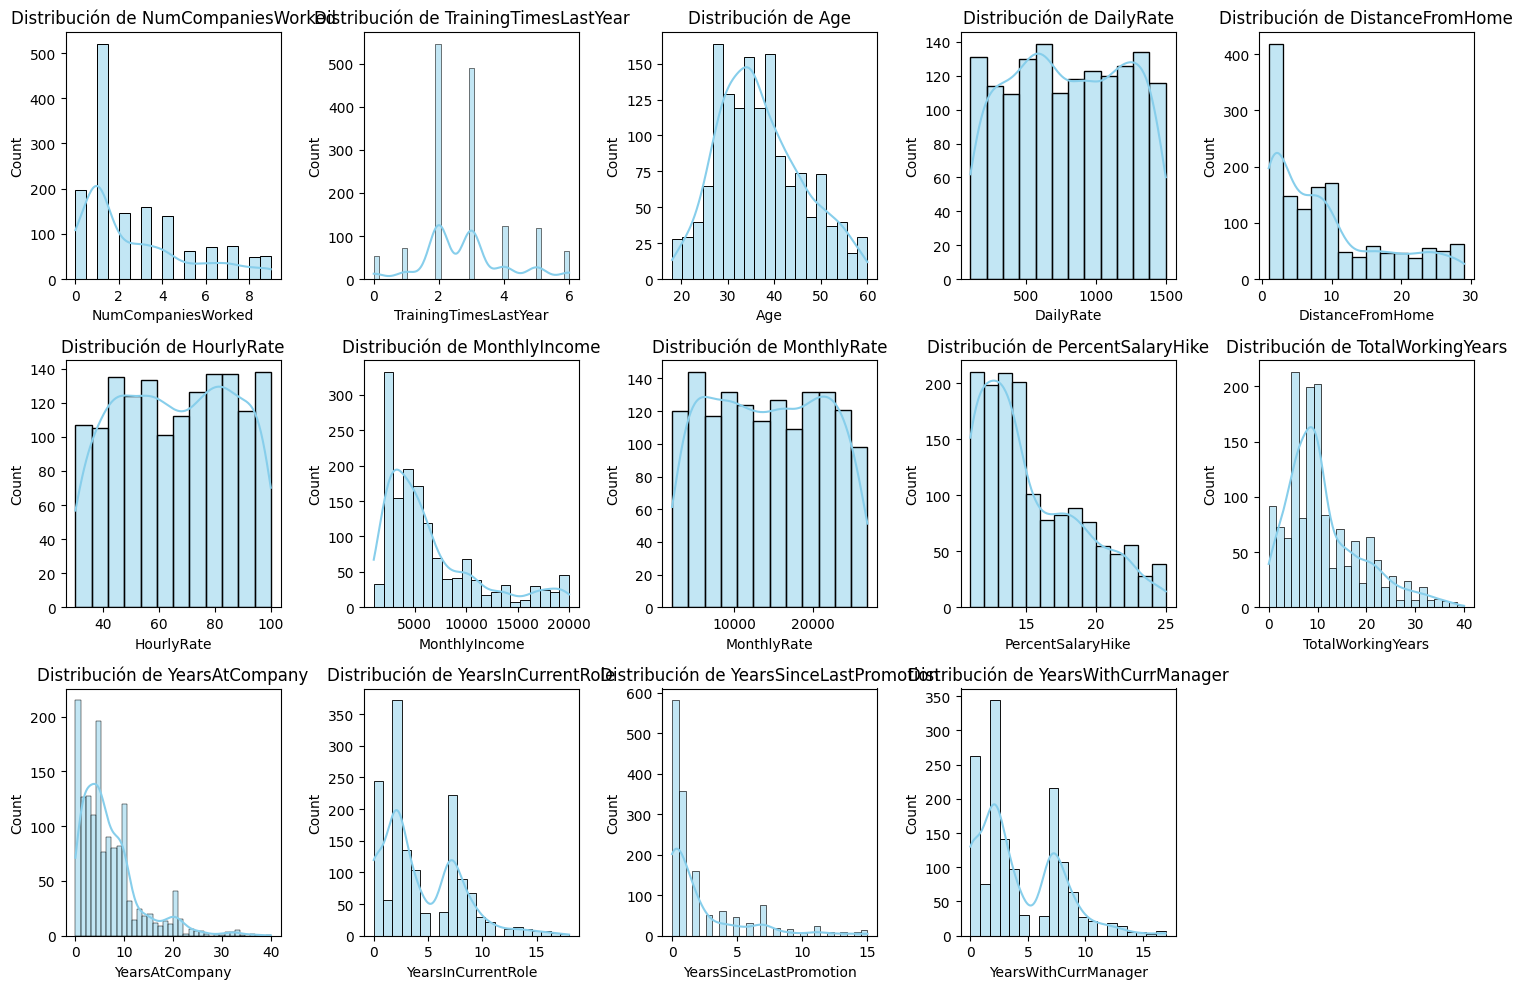

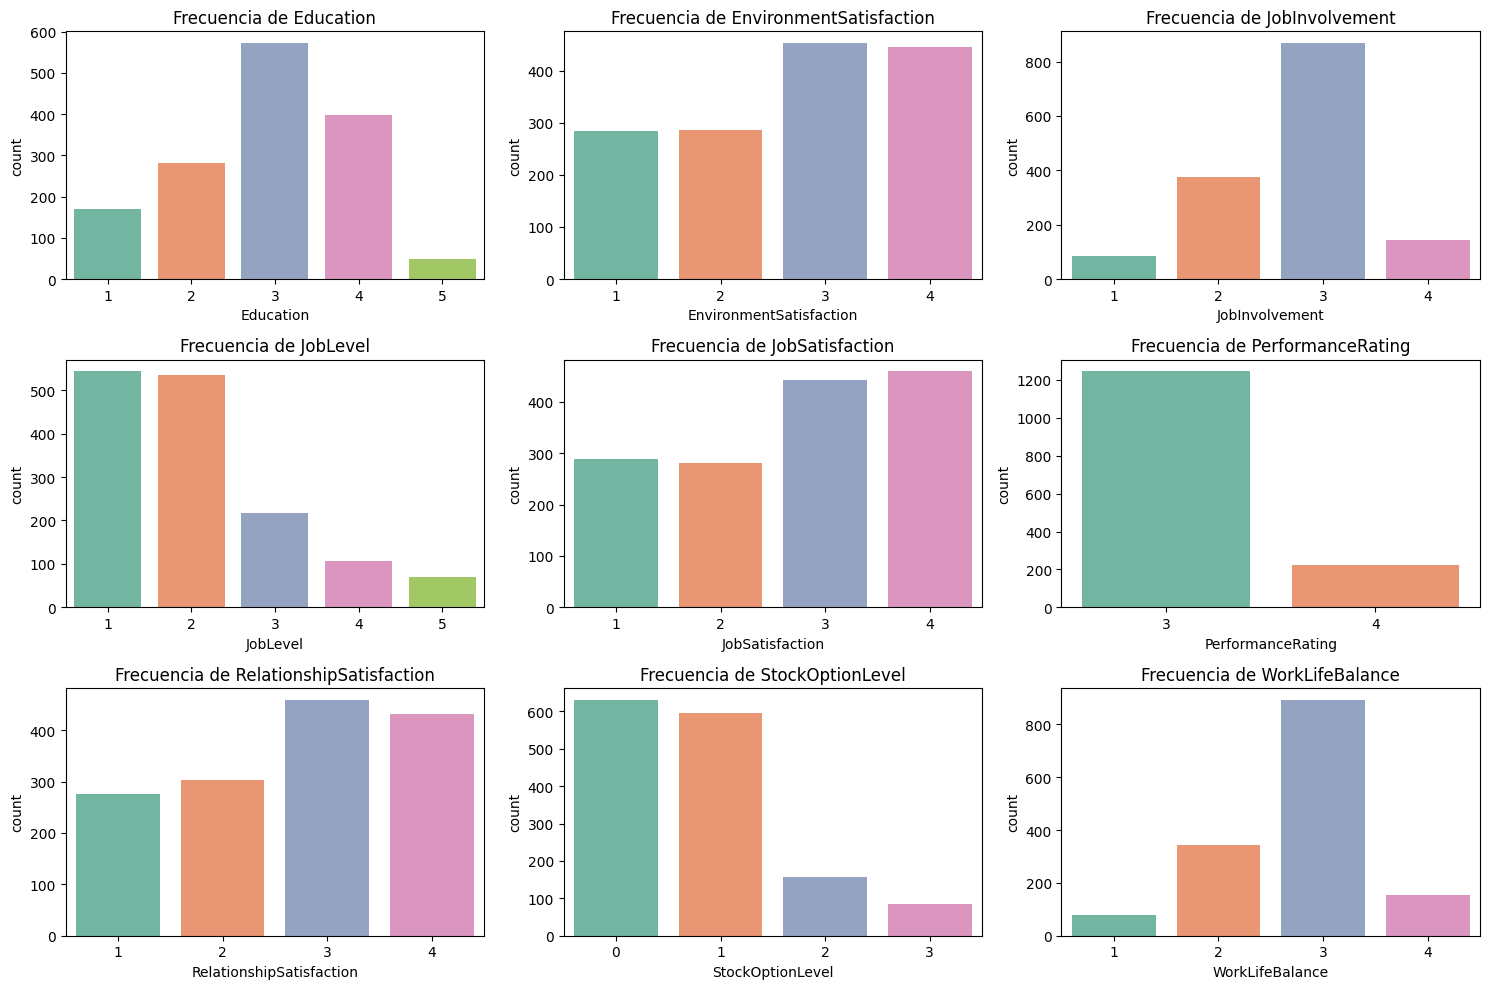

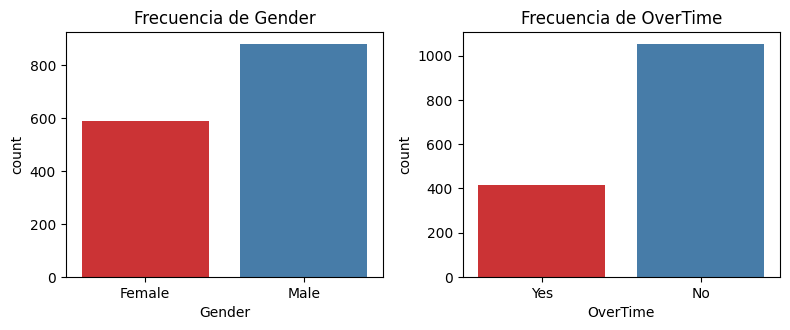

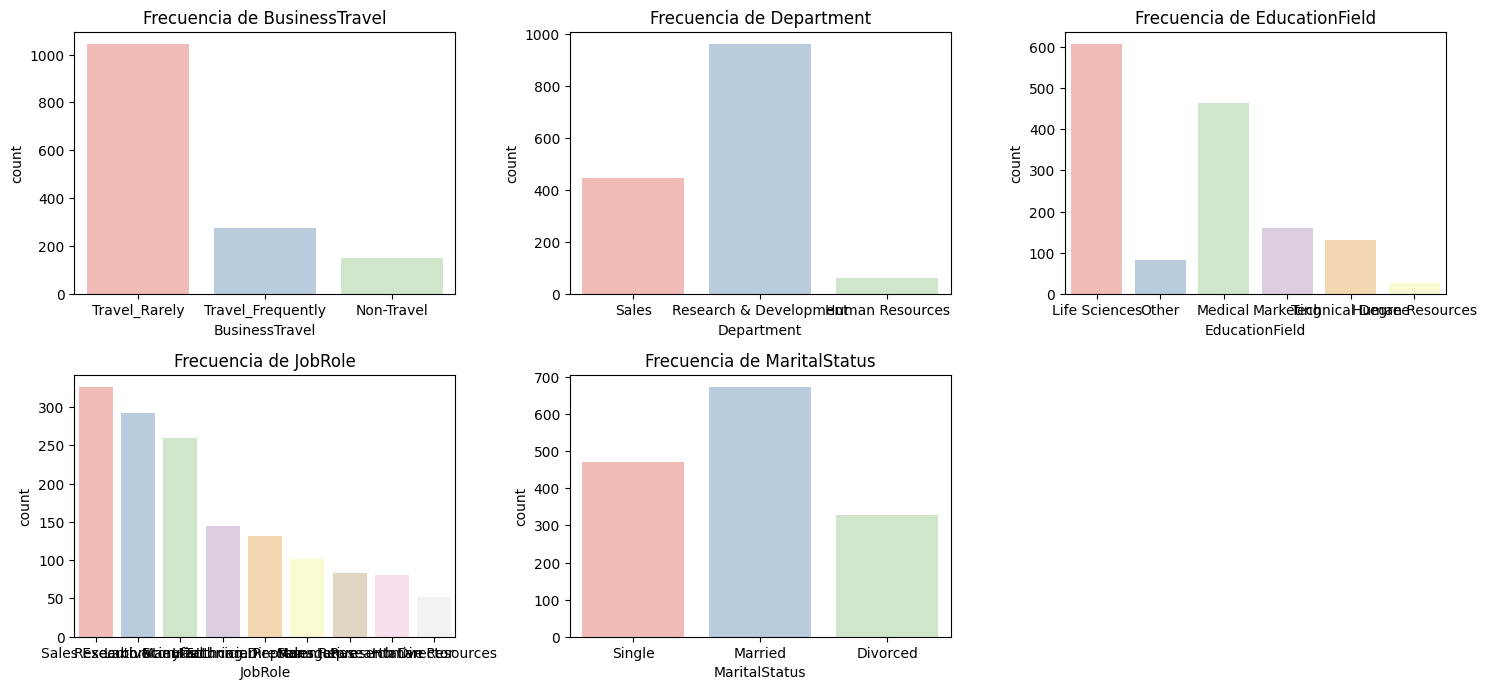

In [ ]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# Incluye en esta sección todas las celdas que consideres conveniente.

print("Estadísticas Descriptivas para Variables Numéricas:")
print(df.describe())

# Análisis de las variables numéricas
numeric_columns = ['NumCompaniesWorked', 'TrainingTimesLastYear', 'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
                   'MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany',
                   'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

# Graficar distribuciones de variables numéricas
plt.figure(figsize=(15, 10))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(3, 5, i)
    sns.histplot(df[column], kde=True, color='skyblue')
    plt.title(f'Distribución de {column}')
plt.tight_layout()
plt.show()

# Análisis de las variables ordinales
ordinal_columns = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
                   'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

# Graficar distribuciones de variables ordinales
plt.figure(figsize=(15, 10))
for i, column in enumerate(ordinal_columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=df[column], palette='Set2', hue=df[column], legend=False)
    plt.title(f'Frecuencia de {column}')
plt.tight_layout()
plt.show()

# Análisis de las variables binarias
binary_columns = ['Gender', 'OverTime']

# Graficar distribución de variables binarias
plt.figure(figsize=(8, 6))
for i, column in enumerate(binary_columns, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=df[column], palette='Set1', hue=df[column], legend=False)
    plt.title(f'Frecuencia de {column}')
plt.tight_layout()
plt.show()

# Análisis de las variables nominales
nominal_columns = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

# Graficar distribución de variables nominales
plt.figure(figsize=(15, 10))
for i, column in enumerate(nominal_columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=df[column], palette='Pastel1', hue=df[column], legend=False)
    plt.title(f'Frecuencia de {column}')
plt.tight_layout()
plt.show()
# El analisis es clave en este aspecto ya que podemos observar que tenemos un desbalance de clasificación considerable
# Las transformaiones juegan un rol fundamental para tener una buena distribución
# Cada Tipo de variable cuenta con su propio procemiento de transformación
# Num mediana, Ord Moda, Bin Moda y Nominales Moda con un encoder
# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



# **Ejercicio 8:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberán aplicarse a cada variable de acuerdo a su tipo.**



In [ ]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

# NUMÉRICAS:
numericas_pipeline = Pipeline(steps=[
    ('impMediana', SimpleImputer(strategy='median')),        # Imputación usando la mediana
    ('escalaNum', MinMaxScaler(feature_range=(1, 2)))       # Escalado en rango (1, 2)
])
numericas_pipeline_nombres = numeric_columns

# ORDINALES:
catOrd_pipeline = Pipeline(steps=[
    ('impModa', SimpleImputer(strategy='most_frequent'))    # Imputación con la moda
])
catOrd_pipeline_nombres = ordinal_columns

# BINARIAS:
catBin_pipeline = Pipeline(steps=[
    ('impModa', SimpleImputer(strategy='most_frequent')),   # Imputación con la moda
    ('OneHotE', OneHotEncoder(handle_unknown='ignore', drop='first'))  # Codificación One-Hot, sin primera categoría
])
catBin_pipeline_nombres = binary_columns

# NOMINALES:
catNom_pipeline = Pipeline(steps=[
    ('impModa', SimpleImputer(strategy='most_frequent')),   # Imputación con la moda
    ('OneHotE', OneHotEncoder(handle_unknown='ignore', drop='first'))  # Codificación One-Hot sin primera categoría
])
catNom_pipeline_nombres = nominal_columns

columnasTransformer = ColumnTransformer(transformers=[
    ('numpipe', numericas_pipeline, numericas_pipeline_nombres),
    ('catord', catOrd_pipeline, catOrd_pipeline_nombres),
    ('catnom', catNom_pipeline, catNom_pipeline_nombres),
    ('catbin', catBin_pipeline, catBin_pipeline_nombres)
], remainder='passthrough')

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

# **Ejercicio 9:**

#### **Reagrupa los conjuntos de entrenamiento y validación en un solo DataFrame.**

#### **A estos nuevos DataFrame llamarlos Xtv y ytv.**

In [ ]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


Xtv = pd.concat([Xtrain, Xval], ignore_index=True)  # Reagrupar las características
ytv = pd.concat([pd.Series(ytrainT, name='Attrition'), pd.Series(yvalT, name='Attrition')], ignore_index=True)  # Reagrupar las etiquetas



# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

print(Xtv.shape)
print(ytv.shape)

(1249, 30)
(1249,)


# **Ejercicio 10:**

#### **Busca los mejores hiperparámetros.**

>> LR 0.874 (0.013)
>> LASSO 0.880 (0.011)
>> RIDGE 0.876 (0.012)
>> EN 0.882 (0.011)
>> kNN 0.844 (0.011)


<ipython-input-143-5af0fbe0060d>:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados, labels=nombres, showmeans=True)   # gráficos de caja para una comparación visual de los resultados.


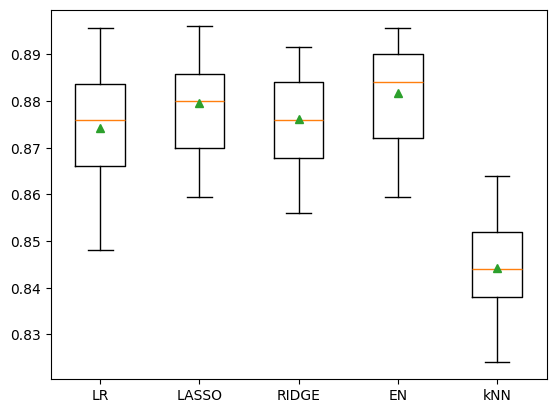

In [ ]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


def mis_modelos():
  modelos, nombres = list(), list()

  # LR - Regresión Logística sin regularización:
  modelos.append(LogisticRegression(penalty=None,  # Este valor de "penalty" no se debe de cambiar, ya que define el modelo sin regularización.
                                    solver='lbfgs', max_iter=2000,     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    random_state=1))
  nombres.append('LR')


  # Lasso - Regresión Logística con regularización L1:
  modelos.append(LogisticRegression(penalty='l1',
                                    solver='liblinear', max_iter=2000, C=1.,     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    random_state=1))
  nombres.append('LASSO')


  # Ridge - Regresión Logística con regularización L2:
  modelos.append(LogisticRegression(penalty='l2',
                                    solver='liblinear', max_iter=2000, C=10.01,     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    random_state=1))
  nombres.append('RIDGE')


  # Elastic_Net - - Regresión Logística con regularización L1 y L2:
  modelos.append(LogisticRegression(penalty='elasticnet',
                                    l1_ratio=0.5, solver='saga', max_iter=4000, C=1.,     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    random_state=1))
  nombres.append('EN')



  # kNN - k-Vecinos más cercanos:
  modelos.append(KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean')) # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
  nombres.append('kNN')

  return modelos, nombres

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



# Entrenamos los modelos:

modelos, nombres = mis_modelos()  # accesando los modelos.
resultados = list()    # para guardar los resultados en esta lista.

# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])   # Transformaciones y modelo en un Pipeline.

  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)     # Aplicando una de las variantes de Validación Cruzada.

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)   # entrenando y generando los resultados.

  resultados.append(scores)    # guardando los resultados en la lista.
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))  # desplegando los promedios de cada modelo.


plt.boxplot(resultados, labels=nombres, showmeans=True)   # gráficos de caja para una comparación visual de los resultados.
plt.show()

# **Ejercicio 11:**

#### **Utilizando el mejor modelo y los datos Xtv, ytv, realiza una búsqueda de malla para encontrar los mejores hiperparámetros. Verifica que el modelo no esté subentrenado o sobreentrenado.**



In [ ]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

# EN fue el mejor
mejor_modelo = LogisticRegression(penalty='elasticnet',
                                   l1_ratio=0.5,
                                   solver='saga',
                                   max_iter=4000,
                                   C=1.,
                                   random_state=1)

dicc_grid = {'C': [0.5, 1., 3.],
             'l1_ratio': [0.1, 0.3, 0.5, 0.7],
             'solver': ['saga']
             }

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=8)

grid = GridSearchCV(estimator=mejor_modelo,
                    param_grid=dicc_grid,
                    cv=cv,
                    scoring='accuracy',
                    n_jobs=-1,
                    return_train_score=True
                    )


Xx = columnasTransformer.fit_transform(Xtv)

grid_result = grid.fit(Xx, np.ravel(ytv))


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++



print("Mejor modelo: %f usando %s" % (grid_result.best_score_, grid_result.best_params_))
print('Promedios Train mean(std): %.4f(%.4f)' % (np.nanmean(grid_result.cv_results_['mean_train_score']),
                                                 np.nanmean(grid_result.cv_results_['std_train_score'])))
print('Promedios Val mean(std): %.4f(%.4f)' % (grid_result.cv_results_['mean_test_score'].mean(),
                                               grid_result.cv_results_['std_test_score'].mean()))


Mejor modelo: 0.880425 usando {'C': 1.0, 'l1_ratio': 0.7, 'solver': 'saga'}
Promedios Train mean(std): 0.8914(0.0039)
Promedios Val mean(std): 0.8791(0.0153)


# **Ejercicio 12:**

#### **Con los mejores valores de hiperparámetros del mejor modelo encontrado, obtener:**

*   #### **a) Matriz de Confusión.**
*   #### **b) Análisis de Imprtancia de Factores.**
*   #### **c) Reporte de métricas.**

Matriz de Confusión:


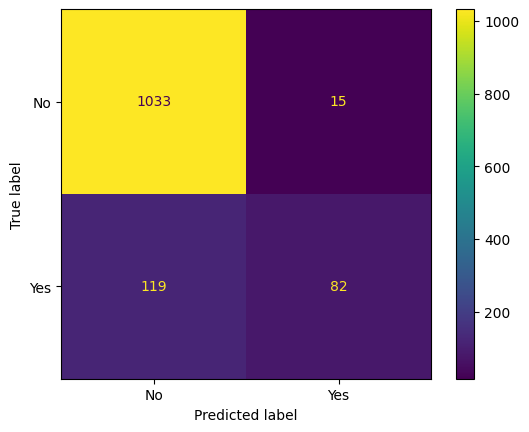

Importancia de Factores:
                               Característica  Coeficiente  Importancia
12           numpipe__YearsSinceLastPromotion     1.954908     1.954908
43                       catbin__OverTime_Yes     1.640795     1.640795
11                numpipe__YearsInCurrentRole    -1.446533     1.446533
23   catnom__BusinessTravel_Travel_Frequently     1.427727     1.427727
0                 numpipe__NumCompaniesWorked     1.345822     1.345822
4                   numpipe__DistanceFromHome     1.182275     1.182275
13              numpipe__YearsWithCurrManager    -1.159108     1.159108
41               catnom__MaritalStatus_Single     0.961497     0.961497
2                                numpipe__Age    -0.956927     0.956927
33      catnom__JobRole_Laboratory Technician     0.892734     0.892734
10                    numpipe__YearsAtCompany     0.881209     0.881209
25  catnom__Department_Research & Development    -0.770794     0.770794
1              numpipe__TrainingTimesLa

In [ ]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++
# Incluye todas las celdas que consideres adecuado para responder
# estos tres incisos del ejercicio.

modelo_mejor = LogisticRegression(
    penalty='elasticnet',
    l1_ratio=0.7,
    solver='saga',
    max_iter=2000,
    C=1.0,
    random_state=1
)

# Ajusta el modelo a los datos de entrenamiento transformados
Xx = columnasTransformer.fit_transform(Xtv)
mejor_result = modelo_mejor.fit(Xx, np.ravel(ytv))

# Predicciones sobre el conjunto de prueba
y_pred = mejor_result.predict(Xx)

# a) Matriz de Confusión
print("Matriz de Confusión:")
ConfusionMatrixDisplay.from_estimator(mejor_result, Xx, np.ravel(ytv), display_labels=['No', 'Yes'])
plt.show()

# b) Análisis de Importancia de Factores
print("Importancia de Factores:")
coef = mejor_result.coef_.flatten()
importancia_factors = pd.DataFrame({
    'Característica': columnasTransformer.get_feature_names_out(),
    'Coeficiente': coef,
    'Importancia': abs(coef)
}).sort_values(by='Importancia', ascending=False)
print(importancia_factors)

# c) Reporte de Métricas
print("Reporte de Métricas:")
reporte = classification_report(np.ravel(ytv), y_pred, target_names=['0', '1'])
print(reporte)


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

# **Ejercicio 13**

#### **Obtener el desempeño final del modelo (accuracy) con el conjunto de prueba (test).**

In [ ]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

accuracy = accuracy_score(np.ravel(ytestT), y_pred)  # Use ytestT for evaluation
print("Desempeño final (accuracy):", accuracy)

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

Desempeño final (accuracy): 0.8868778280542986


# **Ejercicio 14**

#### **Incluye tus conclusiones finales de la actividad.**

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++

Esta actividad me ha permitido reflexionar sobre la importancia de la rotación de personal, un problema crítico que afecta a muchas organizaciones. La rotación no solo tiene un impacto directo en la estabilidad de la empresa, sino que también influye en la productividad, los costos operativos y el bienestar general de los empleados. Aquí es donde el aprendizaje automático se presenta como una herramienta valiosa, al permitirnos generar modelos predictivos que pueden ayudarnos a entender mejor los factores que afectan la rotación de personal. Estos modelos pueden, a su vez, asignar significancias a diferentes variables, lo que facilita la identificación de los aspectos clave que influyen en la permanencia de los empleados dentro de la empresa. De esta forma, podemos transformar un conjunto de datos crudo en un modelo práctico que no solo predice la rotación, sino que también sirve como base para una mejor planificación y optimización de las estrategias de recursos humanos.

Desde mi experiencia personal, esta actividad fue muy interesante porque nos permitió utilizar una variedad de herramientas, transformaciones y modelos, lo que proporcionó una comprensión más profunda de cómo aplicar el aprendizaje automático en situaciones del mundo real. Nos enfrentamos a una serie de desafíos, especialmente con el manejo y la creación de variables, lo que reflejó lo complejo que puede ser este proceso cuando las variables no están completamente alineadas o cuando existen discrepancias en las dimensiones de los datos. A pesar de estos retos, creo que aprendí mucho sobre la importancia de tener un buen control de las variables y un seguimiento adecuado a lo largo del proceso, algo que me hubiera ayudado a evitar algunos de los problemas que enfrenté, como las inconsistencias al transformar las etiquetas o el manejo de datos no uniformes.

Si tuviera que realizar una actividad similar en el futuro, sería fundamental tener un enfoque más ordenado, con un control detallado de las variables y un mejor registro de los pasos seguidos. Esto me permitiría gestionar de manera más eficiente los datos y garantizar que las funciones reciban los datos adecuados sin problemas de dimensiones o requerimientos no cumplidos. En resumen, esta actividad no solo fue un desafío técnico, sino también una excelente oportunidad para comprender cómo las herramientas de aprendizaje automático pueden ser un motor clave para optimizar procesos y tomar decisiones informadas en áreas tan cruciales como la rotación de personal.

#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++

# >> **Fin de la Actividad de la Semana 3** <<